In [69]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/burnoutminer/heights-and-weights-dataset/SOCR-HeightWeight.csv


In [70]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [103]:
df=pd.read_csv("/kaggle/input/datasets/burnoutminer/heights-and-weights-dataset/SOCR-HeightWeight.csv")

In [104]:
df.rename(columns={'Height(Inches)': 'height',"Weight(Pounds)":"weight"}, inplace=True)

In [105]:
df.drop(columns=["Index"],inplace=True)

In [106]:
df.describe()

,height,weight
count,25000.000000,25000.000000
mean,67.993114,127.079421
std,1.901679,11.660898
min,60.278360,78.014760
25%,66.704397,119.308675
50%,67.995700,127.157750
75%,69.272958,134.892850
max,75.152800,170.924000


In [107]:
type(df["height"])

pandas.core.series.Series

In [108]:
df

,height,weight
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971
...,...,...
24995,69.50215,118.0312
24996,64.54826,120.1932
24997,64.69855,118.2655
24998,67.52918,132.2682


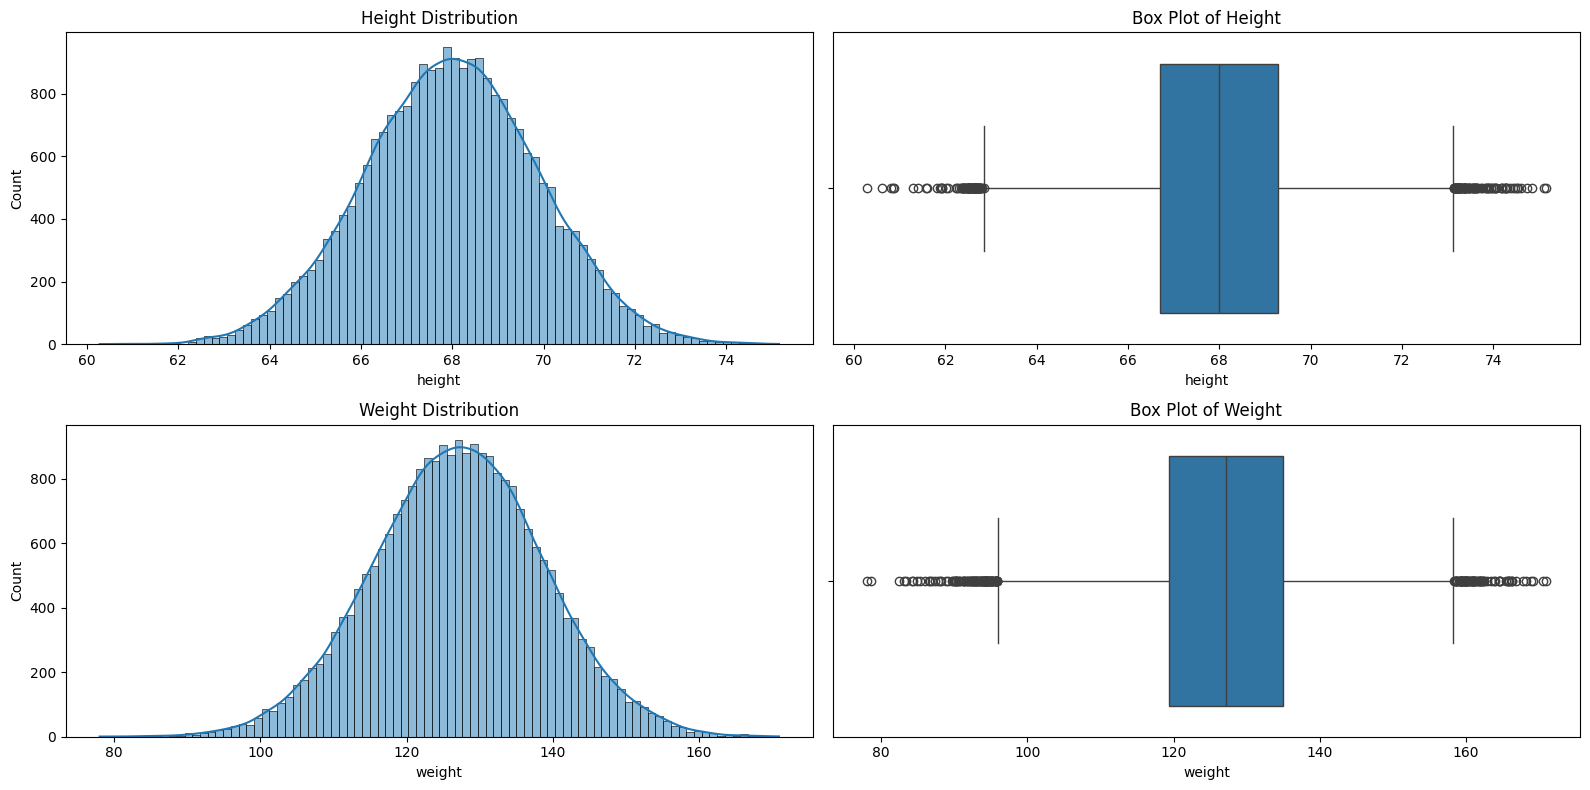

In [162]:

plt.figure(figsize=(16, 8))

# 1st plot
plt.subplot(2, 2, 1)
sns.histplot(df["height"], kde=True)
plt.title("Height Distribution")

# 2nd plot
plt.subplot(2, 2, 2)
sns.boxplot(x=df["height"])
plt.title("Box Plot of Height")

# 3rd plot
plt.subplot(2, 2, 3)
sns.histplot(df["weight"], kde=True)
plt.title("Weight Distribution")

# 4th plot
plt.subplot(2, 2, 4)
sns.boxplot(x=df["weight"])
plt.title("Box Plot of Weight")

plt.tight_layout()
plt.show()

In [163]:
upper_limit=df['height'].quantile(0.99)
lower_limit=df['height'].quantile(0.01)

In [164]:
lower_limit

np.float64(63.5986493)

In [165]:
upper_limit

np.float64(72.37221499999998)

In [166]:
new_df=df[(df["height"]<=upper_limit)&(df['height']>=lower_limit)]
new_df

,height,weight
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971
...,...,...
24995,69.50215,118.0312
24996,64.54826,120.1932
24997,64.69855,118.2655
24998,67.52918,132.2682


In [167]:
new_df.describe()

,height,weight
count,24500.000000,24500.000000
mean,67.992652,127.077687
std,1.779869,11.480110
min,63.598670,82.382980
25%,66.734427,119.395675
50%,67.995700,127.142450
75%,69.244185,134.781375
max,72.372170,170.924000


In [168]:
weight_upper=new_df['weight'].quantile(0.99)
weight_lower=new_df['weight'].quantile(0.01)
print(weight_upper," ",weight_lower)

153.788659   100.29182300000001


# *Remove data for outlier*

In [169]:
new_df = new_df[
    (new_df["weight"] >= 103.35) &
    (new_df["weight"] <= 150.87)
]

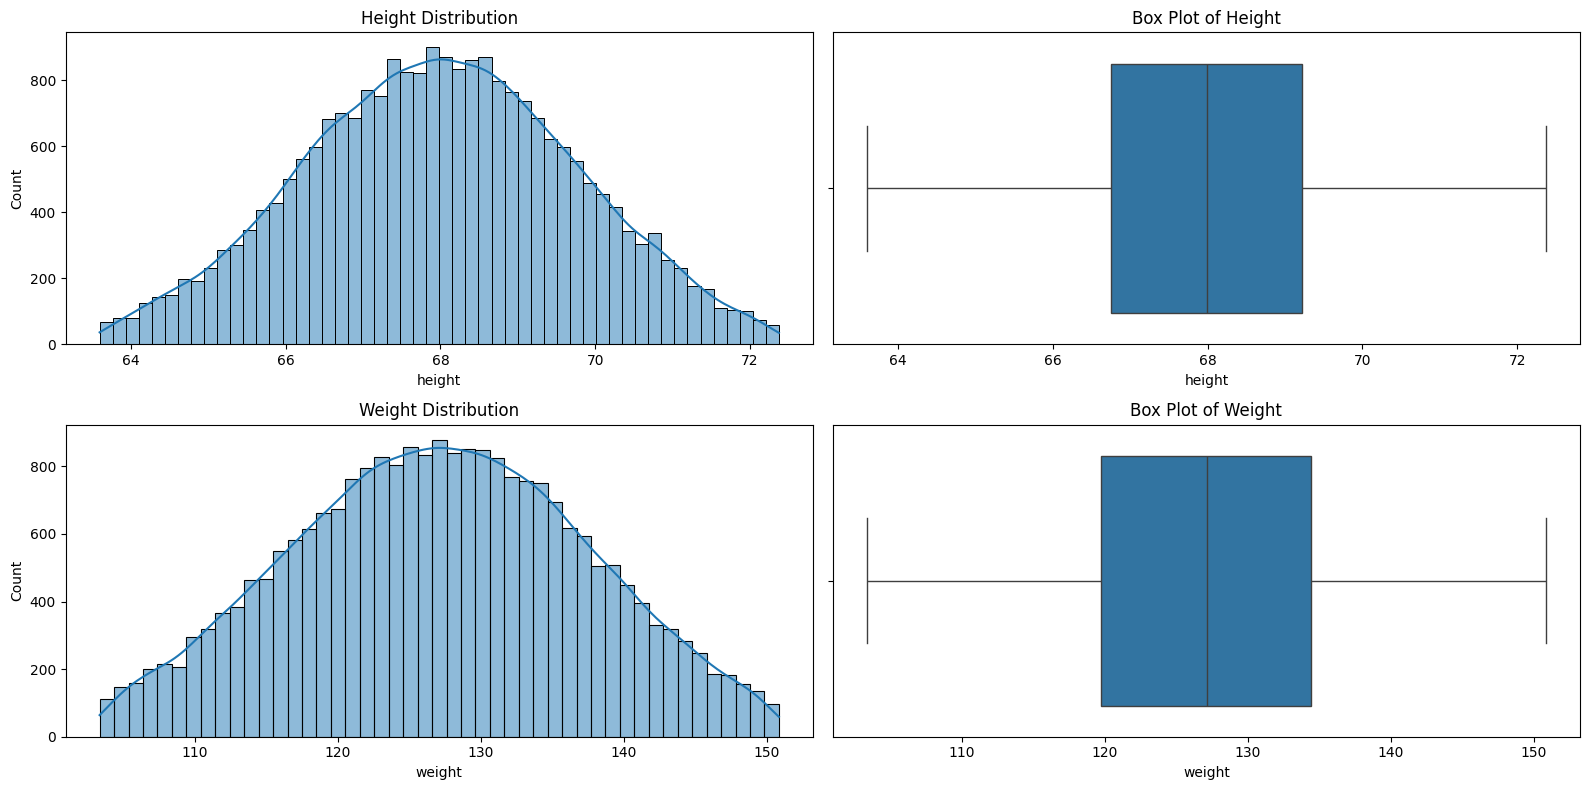

In [170]:

plt.figure(figsize=(16, 8))

# 1st plot
plt.subplot(2, 2, 1)
sns.histplot(new_df["height"], kde=True)
plt.title("Height Distribution")

# 2nd plot
plt.subplot(2, 2, 2)
sns.boxplot(x=new_df["height"])
plt.title("Box Plot of Height")

# 3rd plot
plt.subplot(2, 2, 3)
sns.histplot(new_df["weight"], kde=True)
plt.title("Weight Distribution")

# 4th plot
plt.subplot(2, 2, 4)
sns.boxplot(x=new_df["weight"])
plt.title("Box Plot of Weight")

plt.tight_layout()
plt.show()

In [180]:
new_height=new_df.copy()
new_height.shape

(23530, 2)

In [188]:
new=df.copy()

# *Remove outlier using capping*

In [194]:
new = df.copy()

new["height"] = np.where(
    df["height"] >= upper_limit,
    upper_limit,
    np.where(
        df["height"] <= lower_limit,
        lower_limit,
        df["height"]
    )
)

In [195]:
new

,height,weight
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971
...,...,...
24995,69.50215,118.0312
24996,64.54826,120.1932
24997,64.69855,118.2655
24998,67.52918,132.2682


In [196]:
new["weight"]=pd.DataFrame(np.where(new['weight']>=weight_upper,
                                       weight_upper,
                                       np.where(
                                           new["weight"]<=weight_lower,
                                           weight_lower,
                                           new["weight"]
                                       )
                                      
                                      
                                      ))

In [199]:
new.describe()

,height,weight
count,25000.000000,25000.000000
mean,67.992508,127.085554
std,1.868011,11.422490
min,63.598649,100.291823
25%,66.704397,119.308675
50%,67.995700,127.157750
75%,69.272958,134.892850
max,72.372215,153.788659


In [200]:
new.shape

(25000, 2)

In [202]:
new_df.shape

(23530, 2)

In [203]:
df.shape

(25000, 2)

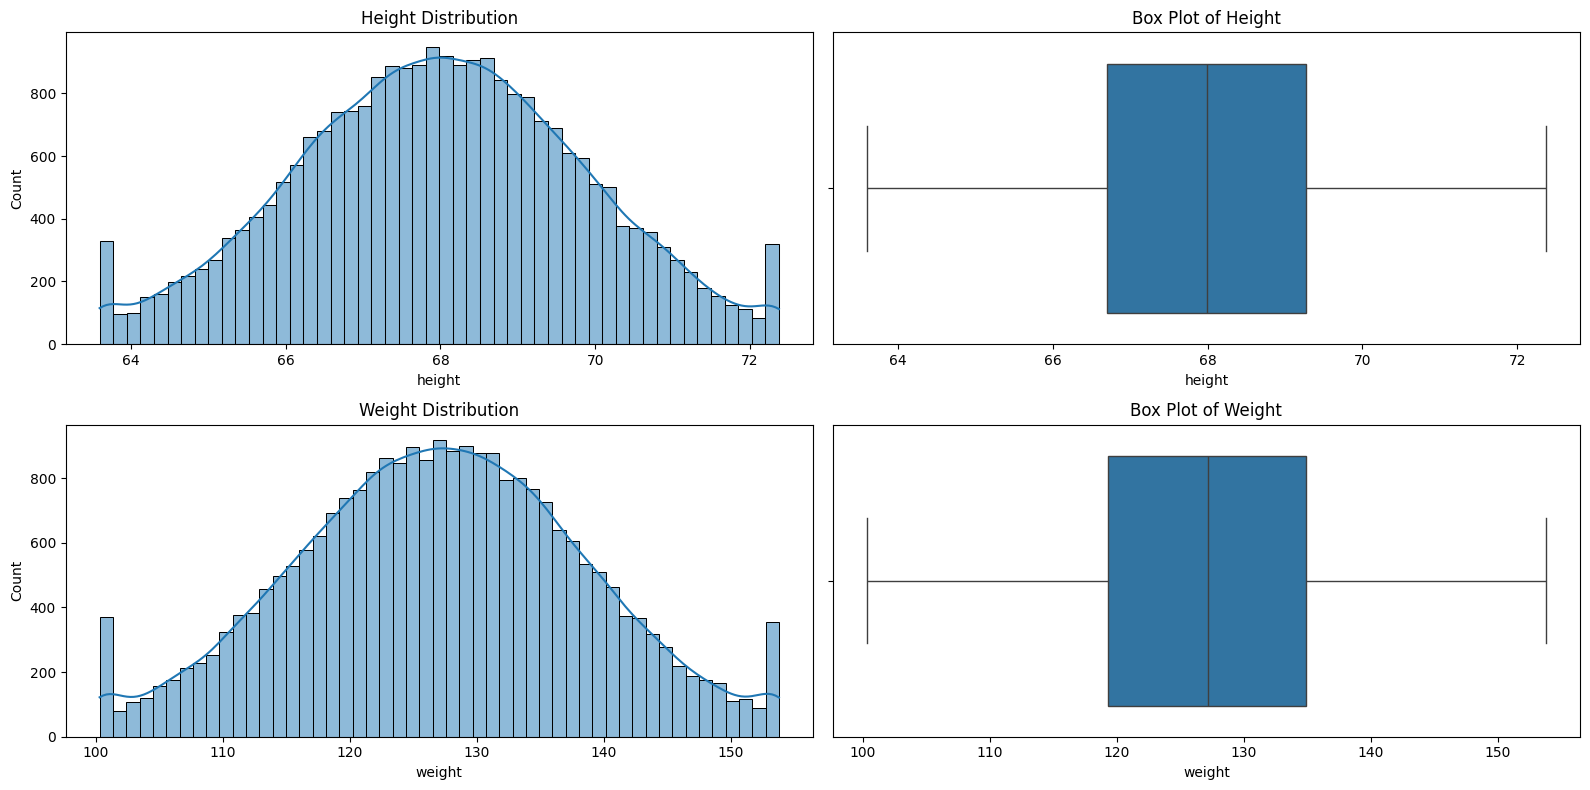

In [205]:

plt.figure(figsize=(16, 8))

# 1st plot
plt.subplot(2, 2, 1)
sns.histplot(new["height"], kde=True)
plt.title("Height Distribution")

# 2nd plot
plt.subplot(2, 2, 2)
sns.boxplot(x=new["height"])
plt.title("Box Plot of Height")

# 3rd plot
plt.subplot(2, 2, 3)
sns.histplot(new["weight"], kde=True)
plt.title("Weight Distribution")

# 4th plot
plt.subplot(2, 2, 4)
sns.boxplot(x=new["weight"])
plt.title("Box Plot of Weight")

plt.tight_layout()
plt.show()